
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

  



In [ ]:
#1)
df_mpg = pd.read_csv("/content/sample_data/millas_por_galon.csv")

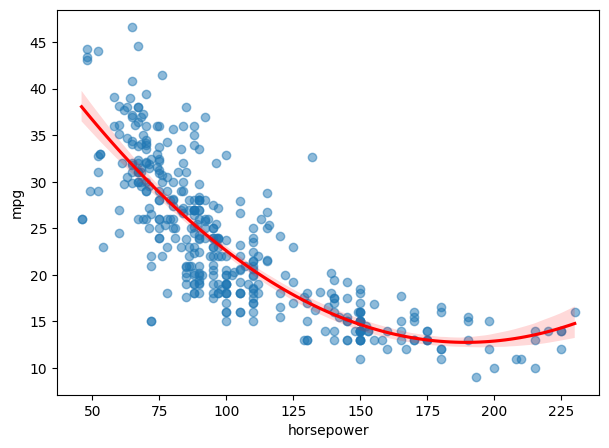

In [ ]:
df_mpg['horsepower'] = pd.to_numeric(df_mpg['horsepower'], errors='coerce')

#saco los datos que voy a comparar
df_mpg = df_mpg.dropna(subset=['mpg', 'horsepower'])

#figura y ejes con el tamaño querido
fig, ax = plt.subplots(figsize=(7, 5))

#gráfica de regresion usando (regplot) que me permite hacer la grafica de dos variables, comparandolas con el 95 ci
sns.regplot(
    data=df_mpg,
    x='horsepower',       # Eje X: Potencia en caballos de fuerza
    y='mpg',              # Eje Y: Millas por galón
    ax=ax,                # Le digo que se dibuje en los ejes que creo arriba en fig, ax
    order = 2,            # Realizo un ajuste en orden dos, para que la curva se adecue a los datos
    ci=95,                # Nivel de confianza al 95% (la banda sombreada roja)
    scatter_kws={'alpha':0.5}, # Transparencia de los puntos al 50%
    line_kws={'color': 'red'}  # Color de la línea de ajuste
)

plt.show()

CONCLUSION??? ECUACION DEL POLI... FALTO MAS ANALISIS

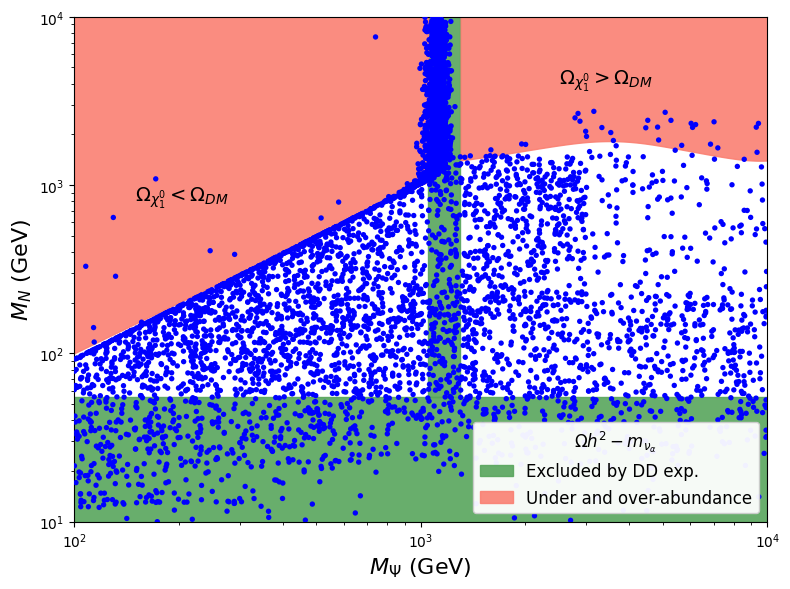

In [ ]:

#2)

df = pd.read_csv('/content/sample_data/general-scan.csv')

# 2. Calcular M_N según la relación dada: M_N = h_s * v_s / sqrt(2)
df['MN'] = (df['YRC'] * df['vS']) / np.sqrt(2)

#empezar la gráfica
plt.figure(figsize=(8, 6))

# Rango del eje X para las regiones sombreadas
x_fill = np.logspace(2, 4, 1000)

# Región verde inferior (Excluida por experimentos de Detección Directa, M_N < ~55 GeV)
plt.fill_between([100, 10000], 10, 55, color='#58A55C', alpha=0.9, label='Excluded by DD exp.')

# Región verde vertical (Excluida por DD, M_Psi aprox entre 1050 y 1300 GeV)
plt.fill_between([1050, 1300], 55, 10000, color='#58A55C', alpha=0.9)

# Región rosada superior izquierda (Sub y sobreabundancia, por encima de M_N = M_Psi)
plt.fill_between(x_fill[x_fill <= 1050], x_fill[x_fill <= 1050], 10000,
                 color='#FA8072', alpha=0.9, label='Under and over-abundance')

# Región rosada superior derecha (Curva donde Omega_chi > Omega_DM)
# Usamos una interpolación para suavizar la frontera basándonos en la figura original
x_curve = [1300, 2000, 3000, 5000, 7000, 10000]
y_curve = [1400, 1600, 1800, 1700, 1500, 1400]
f_interp = interp1d(x_curve, y_curve, kind='cubic', fill_value="extrapolate")

x_right = x_fill[x_fill >= 1300]
y_right = f_interp(x_right)
plt.fill_between(x_right, y_right, 10000, color='#FA8072', alpha=0.9)

#graficar los puntos (scattering)
sns.scatterplot(
    data=df,
    x='MDF',       # M_Psi
    y='MN',        # M_N
    color='blue',
    s=15,          # Tamaño de los marcadores
    edgecolor='none',
    zorder=3       # Asegura que los puntos se dibujen por encima de las regiones sombreadas
)

#configurar escalas logarítmicas y límites de los ejes
plt.xscale('log')
plt.yscale('log')
plt.xlim(100, 10000)
plt.ylim(10, 10000)

#añadir etiquetas de ejes (usando LaTeX para la notación matemática)
plt.xlabel(r'$M_\Psi$ (GeV)', fontsize=16)
plt.ylabel(r'$M_N$ (GeV)', fontsize=16)

#añadir los textos integrados en las regiones rosada
plt.text(150, 800, r'$\Omega_{\chi_1^0} < \Omega_{DM}$', fontsize=14, weight='bold')
plt.text(2500, 4000, r'$\Omega_{\chi_1^0} > \Omega_{DM}$', fontsize=14, weight='bold')

#agregar la leyenda para que coincida con el estilo
plt.legend(
    title=r'$\Omega h^2 - m_{\nu_\alpha}$',
    loc='lower right',
    framealpha=0.95,
    fontsize=12,
    title_fontsize=12
)
#mostrar la gráfica final
plt.tight_layout()
plt.show()

NO HACE LOS FILTROS CON PANDAS... SOLO EL FILBETWEEN
NOTA 2.1+2.3